# 03. Reference mapping: validate the manual cell types against a lung cancer atlas

**Author:** MD Shakhaowat Hossain, Graduate Researcher, Tulane University School of Medicine · [Project website](https://hossainms.github.io/xenium-human-lung-cancer-ffpe/) · [Code](https://github.com/hossainms/xenium-human-lung-cancer-ffpe)

**Why:** the cell types in the core workflow (Step 6) were assigned by hand, from cluster marker genes. That is standard practice, but it is one analyst's judgement. Here every cell is also labelled by a classifier trained on an independent, published reference, and the two labelings are compared **cell type by cell type**. Agreement turns "labelled by hand" into "validated against a reference"; disagreement shows where the manual labels, the panel, or the segmentation are weak.

**Reference:** the core Lung Cancer Atlas (**LuCA**; Salcher et al., *Cancer Cell* 2022): 892,296 cells from 298 donors across 19 studies of non-small cell lung cancer and normal lung, expert-annotated, downloaded from CELLxGENE (CC BY 4.0).

**Method:** the **CellTypist** model (Domínguez Conde et al., *Science* 2022): logistic regression on log-normalised, scaled expression, trained only on the genes shared by the atlas and the Xenium panel.

| Part | Content |
|---|---|
| A | Prepare the reference: download, restrict to panel genes, check sequencing depth |
| B | Train the classifier and measure its ceiling on held-out atlas donors |
| C | Annotate both segmentations (10x and Proseg, from notebook 02) |
| D | Agreement with the manual labels, cell type by cell type |
| E | Export and conclusions |

## Setup

Analysis functions, paths and constants come from the `ist_analysis` package (repository root; `pip install -e .`), shared with the core notebook and the Snakemake pipeline.

In [1]:
from ist_analysis import proseg, reference
from ist_analysis import utils as xu   # paths and constants shared with the core workflow and the pipeline

xu.check_kernel()

import pickle
import time
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
from IPython.display import display


warnings.filterwarnings("ignore", category=FutureWarning)
REF_DIR = xu.DATA_ROOT / "reference"
REF_DIR.mkdir(exist_ok=True)
OUT_DIR = xu.output_dir("reference_mapping")
print(f"Reference files: {xu.display_path(REF_DIR)}\nOutputs: {xu.display_path(OUT_DIR)}")

Reference files: ~/data/xenium_lung/reference
Outputs: ~/data/xenium_lung/processed/reference_mapping


## A. Prepare the reference

### A1. Download and restrict to the panel genes

The atlas is a 12.9 GB `.h5ad` file (CELLxGENE). Only the genes on the Xenium panel are useful for classification, so the atlas is read once, **streamed in blocks of 50,000 cells** (reading it with `anndata`'s backed mode row by row was far slower), restricted to the shared genes, and cached as a small file (~80 MB). Raw counts come from `raw.X`.

Genes are matched by **Ensembl ID**, not symbol, so renamed genes are not lost. 23 panel genes are absent from the atlas; they are markers of non-lung tissues on this multi-tissue panel (INS, GCG, UMOD, ...), so nothing lung-relevant is lost.

`DOWNLOAD_ATLAS = False` (default) skips the download if the file is present; the panel-gene cache is rebuilt only if missing (~17 min).

In [2]:
import requests
from tqdm.auto import tqdm

ATLAS_URL = "https://datasets.cellxgene.cziscience.com/46e0287b-9a33-4e83-99f3-8c044131bfdc.h5ad"   # LuCA core atlas
ATLAS = REF_DIR / "luca_core_atlas.h5ad"
PANEL_REF = REF_DIR / "luca_core_panel_genes.h5ad"
DOWNLOAD_ATLAS = False   # True = download (12.9 GB) when the file is missing

if not ATLAS.exists() and not PANEL_REF.exists():
    if not DOWNLOAD_ATLAS:
        raise FileNotFoundError(f"{xu.display_path(ATLAS)} not found: set DOWNLOAD_ATLAS = True to download it (12.9 GB).")
    with requests.get(ATLAS_URL, stream=True, timeout=60) as r, open(ATLAS, "wb") as fh:
        r.raise_for_status()
        with tqdm(total=int(r.headers["Content-Length"]), unit="B", unit_scale=True, desc="LuCA core atlas") as bar:
            for chunk in r.iter_content(chunk_size=8 << 20):
                bar.update(fh.write(chunk))

ann = xu.load_step("annotated")   # Step 6: manual labels + raw counts for all QC-passing cells

if not PANEL_REF.exists():
    t0 = time.time()
    # stream the atlas in 50,000-cell blocks, keep the panel genes (matched by Ensembl id), cache the result
    reference.build_panel_reference(ATLAS, ann.var["gene_ids"], PANEL_REF)
    print(f"Built the panel-gene cache in {(time.time() - t0) / 60:.0f} min")

panel_ref = ad.read_h5ad(PANEL_REF)
missing = ann.var_names[~ann.var_names.isin(panel_ref.var_names)]
print(f"Atlas: {panel_ref.n_obs:,} cells, {panel_ref.obs['donor_id'].nunique()} donors, {panel_ref.obs['dataset'].nunique()} datasets")
print(f"Panel genes found in the atlas: {panel_ref.n_vars} of {ann.n_vars}")
print(f"Absent ({len(missing)}, non-lung markers of the multi-tissue panel): {', '.join(missing)}")

Atlas: 892,296 cells, 298 donors, 21 datasets
Panel genes found in the atlas: 354 of 377
Absent (23, non-lung markers of the multi-tissue panel): ADIPOQ, AMY2A, APOA5, ASCL3, CCL27, CFHR1, CLCA1, FCN2, GCG, GLYATL1, GYPA, INS, KRT20, MLANA, MTRNR2L11, NAT8, OPRPN, SCGN, SLC22A8, SLC26A3, SST, TMEM174, UMOD


### A2. Which cells to train on, and is the sequencing depth comparable?

**Training cells:** lung tissue only (no lymph node or metastasis sites), droplet / UMI platforms only (Smart-seq2 counts reads, not molecules, so its scale differs), and labelled cells only (LuCA's `other` bucket is dropped). Labels: `cell_type_major` (23 types), the atlas's main level.

**Depth matters.** A classifier learns from what expression looks like at the depth it was trained on. If atlas cells had far more counts on the panel genes than Xenium cells, the classifier would expect markers that Xenium rarely detects, and the reference would have to be **down-sampled** to Xenium depth first. So compare counts per cell on the shared genes, in both data sets.

In [3]:
o = panel_ref.obs
eligible = reference.eligible(o)   # lung tissue, UMI platforms, labelled cells
print(f"Eligible training cells: {eligible.sum():,} of {len(o):,} "
      f"(lung tissue, UMI platforms, labelled), {o.loc[eligible, 'cell_type_major'].nunique()} cell types\n")

shared_genes = panel_ref.var_names
ref_depth = np.asarray(panel_ref[eligible.to_numpy()].X.sum(axis=1)).ravel()
xen_depth = np.asarray(ann[:, shared_genes].layers["counts"].sum(axis=1)).ravel()
depth = pd.DataFrame({f"{name}": np.percentile(v, [10, 25, 50, 75, 90]) for name, v in
                      [("LuCA atlas (scRNA-seq)", ref_depth), ("Xenium (10x segmentation)", xen_depth)]},
                     index=["10th", "25th", "median", "75th", "90th"]).T
display(depth.style.format("{:.0f}").set_caption("Counts per cell on the shared panel genes (percentiles)"))
print("The medians match: the atlas has about as many counts per cell on these genes as Xenium does,\n"
      "so no down-sampling is needed. (scRNA-seq spreads its counts over ~18,000 genes; Xenium spends\n"
      "all of its counts on the panel, so the two end up at similar depth on the panel genes.)")

Eligible training cells: 756,622 of 892,296 (lung tissue, UMI platforms, labelled), 23 cell types



,10th,25th,median,75th,90th
LuCA atlas (scRNA-seq),14,25,47,89,153
Xenium (10x segmentation),19,29,47,76,113


The medians match: the atlas has about as many counts per cell on these genes as Xenium does,
so no down-sampling is needed. (scRNA-seq spreads its counts over ~18,000 genes; Xenium spends
all of its counts on the panel, so the two end up at similar depth on the panel genes.)


## B. Train the classifier

### B1. Training, with held-out donors as a ceiling

**Balanced training set:** up to 5,000 cells per cell type, so abundant types (alveolar macrophages: 115k cells) do not drown rare ones (mature DCs: 2k).

**Held-out test:** 20% of **donors** (not 20% of cells) are kept out of training. Cells from one donor are more alike than cells from different donors, so a random-cell split would overstate accuracy. Accuracy on unseen donors is the **ceiling**: how well 354 genes can separate these 23 types at all, before any Xenium-specific problem (segmentation, platform) enters.

**Normalisation:** each cell is scaled to 10,000 counts over the shared genes only, then log1p, identically for atlas and Xenium cells. Normalising the atlas over all 18,000 genes and the Xenium cells over 354 would put them on different scales.

**Model:** CellTypist's recipe (scale each gene, then L2-regularised logistic regression), fit directly with scikit-learn. Two reasons not to call the `celltypist` package itself here:
- its default trainer (v1.7.1) passes an option (`multi_class`) that scikit-learn 1.9 removed, so it fails in this environment;
- its fallback SGD trainer runs, but gave **uncalibrated probabilities** on Xenium cells (median top probability ~0), because it fits each cell type separately (one-vs-rest).

A single multinomial model gives probabilities that sum to 1 across the 23 types, so "probability 0.85" means what it says. It trains in seconds on 100,000 cells.

Trained on 101,745 cells (180 donors) in 7 s
Accuracy on 19,110 cells from 45 unseen donors: 87%



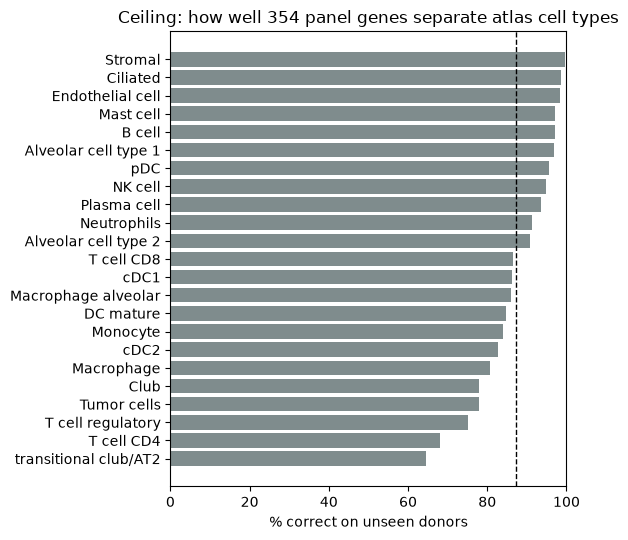

In [4]:
CAP = 5000   # training cells per cell type, at most
train_idx, test_idx, test_donors, donors = reference.donor_split(o, eligible, test_fraction=0.2, max_per_type=CAP)
lognorm = reference.lognorm   # raw counts on the shared genes -> 10,000 per cell -> log1p (CellTypist's input)

t0 = time.time()
model = reference.train_model(lognorm(panel_ref[train_idx], shared_genes), o.loc[train_idx, "cell_type_major"].astype(str).to_numpy())
print(f"Trained on {len(train_idx):,} cells ({len(donors) - len(test_donors)} donors) in {time.time() - t0:.0f} s")
with open(OUT_DIR / "luca_panel_genes_model.pkl", "wb") as fh:
    pickle.dump({"model": model, "genes": list(shared_genes)}, fh)

held = reference.predict(model, lognorm(panel_ref[test_idx], shared_genes), test_idx)["atlas_label"].to_numpy()
truth = o.loc[test_idx, "cell_type_major"].astype(str).to_numpy()
ceiling = pd.Series(held == truth).groupby(truth).mean().sort_values()
print(f"Accuracy on {len(test_idx):,} cells from {len(test_donors)} unseen donors: {(held == truth).mean():.0%}\n")

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.barh(ceiling.index, 100 * ceiling.to_numpy(), color="#7f8c8d")
ax.axvline(100 * (held == truth).mean(), color="black", lw=1, ls="--")
ax.set_xlabel("% correct on unseen donors")
ax.set_title("Ceiling: how well 354 panel genes separate atlas cell types")
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

**Reading the ceiling.** Types with a clean marker on the panel (B, plasma, mast, endothelial, stromal, NK, neutrophils) are recognised almost perfectly even from atlas cells this shallow. The hard ones are pairs that differ in degree rather than kind: CD4 T vs regulatory T, macrophage vs alveolar macrophage, tumour vs transitional club/AT2 epithelium. Disagreement on those pairs in Part D is expected from the panel alone, and is not evidence that the manual labels are wrong.

## C. Annotate the Xenium cells

Both segmentations are labelled with the same model:
- **10x segmentation:** the QC-passing cells of the core workflow (Step 4/6, 154,394 cells).
- **Proseg:** the re-segmented cells from notebook 02, with the same QC as notebook 02 Part E1.

Each cell gets the most probable atlas type and its **probability** (the classifier's probabilities across the 23 types sum to 1).

In [5]:
# ---- 10x segmentation: Step 6 cells
atlas10 = reference.predict(model, lognorm(ann, shared_genes), ann.obs_names)

# ---- Proseg segmentation (notebook 02 export), same QC as notebook 02 Part E1
pro, _ = proseg.qc_proseg(sc.read_h5ad(xu.output_dir("resegmentation") / f"{xu.SAMPLE}_proseg_counts.h5ad"))
atlasP = reference.predict(model, lognorm(pro, shared_genes), pro.obs_names)

summary = pd.DataFrame({
    "cells annotated": [len(atlas10), len(atlasP)],
    "median probability": [atlas10["atlas_prob"].median(), atlasP["atlas_prob"].median()],
    "cells with probability >= 0.5": [(atlas10["atlas_prob"] >= 0.5).mean(), (atlasP["atlas_prob"] >= 0.5).mean()],
}, index=["10x segmentation", "Proseg"])
display(summary.style.format({"cells annotated": "{:,}", "median probability": "{:.2f}",
                              "cells with probability >= 0.5": "{:.0%}"}))
counts = pd.DataFrame({"10x": atlas10["atlas_label"].value_counts(), "Proseg": atlasP["atlas_label"].value_counts()}).fillna(0).astype(int)
display(counts.sort_values("10x", ascending=False).T)

,cells annotated,median probability,cells with probability >= 0.5
10x segmentation,"154,394",0.85,91%
Proseg,"143,975",0.86,92%


atlas_label,transitional club/AT2,Tumor cells,Stromal,Endothelial cell,Plasma cell,Macrophage alveolar,Alveolar cell type 2,Macrophage,T cell CD4,T cell regulatory,...,B cell,cDC2,T cell CD8,Mast cell,DC mature,cDC1,Alveolar cell type 1,Neutrophils,pDC,NK cell
10x,47593,31572,22128,6796,6049,6029,5701,5650,5072,2616,...,2018,1629,1094,967,950,455,395,195,160,118
Proseg,44134,27402,20429,6948,5152,3933,4859,6779,6346,3680,...,1673,2162,1596,1010,585,374,328,199,107,148


## D. Agreement with the manual labels

### D1. Lineage level

Atlas types are grouped into the same 7 lineages as Step 6 (e.g. *Tumor cells*, *Alveolar cell type 2* and *Ciliated* are all Epithelial), and only cells the core workflow labelled with **high confidence** are compared: the `mixed` cells are, by definition, not one cell type. Each row of the heatmap is a manual lineage; read across to see where the atlas put those cells.

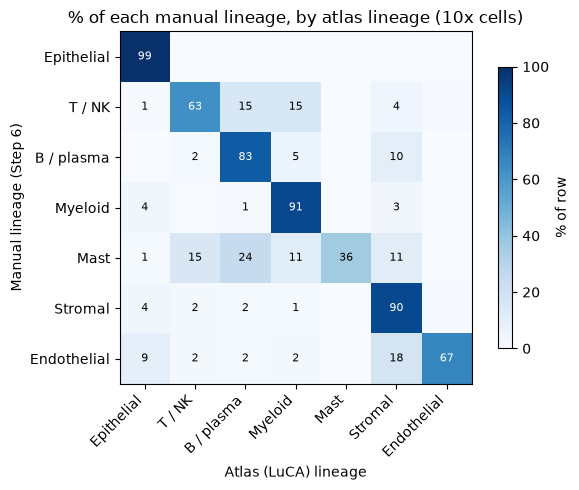

Lineage agreement on 139,129 high-confidence cells: 92.0%


In [6]:
ATLAS_LINEAGE = reference.ATLAS_LINEAGE   # atlas type -> the 7 Step 6 lineages
assert set(ATLAS_LINEAGE) == set(model.classes_), "every atlas type needs a lineage"
LINEAGES = list(xu.LINEAGE_COLORS)

manual = ann.obs[["cell_type", "lineage", "annotation_confidence"]].astype(str)
high = manual.index[manual["annotation_confidence"] == "high"]
both = pd.DataFrame({"manual": manual.loc[high, "lineage"],
                     "atlas": atlas10.loc[high, "atlas_label"].map(ATLAS_LINEAGE)})
lin_tab = pd.crosstab(both["manual"], both["atlas"], normalize="index").reindex(index=LINEAGES, columns=LINEAGES).fillna(0) * 100

fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(lin_tab.to_numpy(), cmap="Blues", vmin=0, vmax=100)
ax.set_xticks(range(len(LINEAGES)), LINEAGES, rotation=45, ha="right")
ax.set_yticks(range(len(LINEAGES)), LINEAGES)
for i in range(len(LINEAGES)):
    for j in range(len(LINEAGES)):
        v = lin_tab.iat[i, j]
        if v >= 1:
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8, color="white" if v > 60 else "black")
ax.set_xlabel("Atlas (LuCA) lineage")
ax.set_ylabel("Manual lineage (Step 6)")
ax.set_title("% of each manual lineage, by atlas lineage (10x cells)")
fig.colorbar(im, ax=ax, shrink=0.8, label="% of row")
plt.tight_layout()
plt.show()
print(f"Lineage agreement on {len(high):,} high-confidence cells: {(both['manual'] == both['atlas']).mean():.1%}")

### D2. Cell type by cell type

For every manual cell type, the atlas types that would **confirm** it are written down in advance (e.g. *CD163+ macrophage* is confirmed by *Macrophage*, *Alveolar macrophage* by *Macrophage alveolar*). The table reports, per manual type, the % of cells the atlas confirms, the atlas's most common call, and the median classifier probability. The ceiling from Part B is shown alongside: a manual type cannot be confirmed more often than the atlas can recognise its own version of that type.

In [7]:
CONFIRMED_BY = reference.CONFIRMED_BY     # manual type (Step 6) -> atlas types that agree with it
ann_types = set(manual.loc[high, "cell_type"])
assert ann_types <= set(CONFIRMED_BY), f"no expectation written for: {ann_types - set(CONFIRMED_BY)}"


def agreement(atlas, cells):
    """Per manual type: % confirmed by the atlas, most common call, median probability, atlas ceiling."""
    return reference.agreement(atlas, manual, cells, ceiling)


agree10 = agreement(atlas10, high)
display(agree10.style.format({"cells": "{:,}", "% confirmed by atlas": "{:.0f}", "median probability": "{:.2f}",
                              "atlas ceiling (%)": "{:.0f}"})
        .background_gradient(subset=["% confirmed by atlas"], cmap="RdYlGn", vmin=0, vmax=100))

,lineage,cells,% confirmed by atlas,most common atlas call,median probability,atlas ceiling (%)
manual type,,,,,,
Tumour epithelial (MALL/TCIM),Epithelial,"25,301",30,transitional club/AT2 (61%),0.81,78
Tumour epithelial (CYP2B6/CFTR),Epithelial,"27,886",20,transitional club/AT2 (65%),0.80,78
Tumour epithelial (MYC/CAPN8),Epithelial,"27,699",49,Tumor cells (49%),0.81,78
Proliferating tumour,Epithelial,"3,826",87,Tumor cells (87%),0.98,78
Ciliated epithelial,Epithelial,"1,028",87,Ciliated (87%),1.00,98
CD8 T (GZMK+),T / NK,"3,811",18,T cell CD4 (29%),0.67,87
Treg,T / NK,681,52,T cell regulatory (52%),0.87,75
NK,T / NK,633,16,T cell CD8 (18%),0.73,95
Proliferating T,T / NK,872,56,T cell regulatory (28%),0.72,77


**Reading D2.** Three groups:
- **Confirmed** (>= 75%, close to the ceiling): ciliated, B, plasma, alveolar macrophage, mregDC, fibroblast, smooth muscle, proliferating tumour. Monocytes are confirmed as *Neutrophils / Monocyte*, matching the R workflow's SingleR result that this S100A12+ group is neutrophil-like.
- **Right lineage, finer call uncertain** (40-70%): the macrophage subtypes, endothelial, Treg, cDC1 / cDC2. Their atlas ceilings (75-86%) already show these are hard to separate on 354 genes.
- **Tumour subtypes:** the atlas calls most MALL/TCIM and CYP2B6/CFTR cells *transitional club/AT2*, not *Tumor cells*. This does not contradict the manual call. LuCA identified malignant cells by **copy-number inference** on whole transcriptomes, which a 354-gene panel cannot reproduce; its *transitional club/AT2* cells come mostly from tumour samples (77% primary tumour). Expression alone confirms these cells are lung epithelium of an alveolar/club-like programme; whether they are malignant needs copy-number evidence.
- **Poorly confirmed** (< 40%): CD8 T, NK, mast, lymphatic endothelial. D4 below shows why.

### D3. Does cleaner segmentation raise agreement?

Same cells, same manual labels, same classifier: only the counts change (10x vs Proseg segmentation; cells are paired by their 10x id). If spillover was making cells look like their neighbours, Proseg counts should be confirmed by the atlas more often. The `mixed` cells of Step 6 are included here: the question for them is what the atlas calls them once the spillover is removed.

In [8]:
paired = manual.index.intersection(atlasP.index)
print(f"{len(paired):,} cells present in both segmentations\n")
seg = pd.DataFrame({
    "% confirmed, 10x counts": agreement(atlas10, paired.intersection(high))["% confirmed by atlas"],
    "% confirmed, Proseg counts": agreement(atlasP, paired.intersection(high))["% confirmed by atlas"],
})
seg["change (points)"] = seg.iloc[:, 1] - seg.iloc[:, 0]
seg.insert(0, "cells", agreement(atlas10, paired.intersection(high))["cells"])
display(seg.sort_values("change (points)").style.format({"cells": "{:,}", "% confirmed, 10x counts": "{:.0f}",
                                                         "% confirmed, Proseg counts": "{:.0f}", "change (points)": "{:+.0f}"})
        .background_gradient(subset=["change (points)"], cmap="RdBu", vmin=-30, vmax=30))

# Step 6 'mixed' cells: atlas lineage with 10x vs Proseg counts
mixed = paired[manual.loc[paired, "annotation_confidence"].to_numpy() == "mixed"]
mix = pd.DataFrame({"manual": manual.loc[mixed, "cell_type"],
                    "10x": atlas10.loc[mixed, "atlas_label"].map(ATLAS_LINEAGE),
                    "Proseg": atlasP.loc[mixed, "atlas_label"].map(ATLAS_LINEAGE)})
mix_tab = (mix.groupby("manual")[["10x", "Proseg"]]
           .agg(lambda s: f"{s.value_counts(normalize=True).index[0]} ({100 * s.value_counts(normalize=True).iloc[0]:.0f}%)"))
mix_tab.insert(0, "cells", mix["manual"].value_counts())
display(mix_tab.sort_values("cells", ascending=False))

141,396 cells present in both segmentations



,cells,"% confirmed, 10x counts","% confirmed, Proseg counts",change (points)
manual type,,,,
mregDC (LAMP3+),431,78,51,-27
Ciliated epithelial,930,87,73,-14
B cell,"2,110",79,66,-14
Alveolar macrophage,"1,807",84,74,-10
Monocyte,183,72,62,-10
Plasma cell,"3,398",81,72,-9
Lymphatic endothelial,290,15,8,-7
Proliferating tumour,"3,347",88,82,-6
Fibroblast,"14,943",91,86,-6


,cells,10x,Proseg
manual,,,
Myeloid / epithelial mixed,2905,Epithelial (74%),Epithelial (79%)
T / myeloid mixed,2795,Myeloid (43%),T / NK (52%)
CD4 T,2409,T / NK (72%),T / NK (75%)
Myeloid / fibroblast mixed,1974,Myeloid (52%),Myeloid (64%)
T / fibroblast mixed,1739,Stromal (42%),T / NK (52%)
Myeloid / T mixed,1561,Myeloid (81%),Myeloid (68%)
T / epithelial mixed,880,Epithelial (41%),T / NK (65%)


**Reading D3, carefully.** Two opposite effects are mixed in the first table:
- **Selection bias against Proseg.** The manual labels were made *from the 10x counts*: a cell was called mregDC partly because its 10x counts happened to contain LAMP3. Re-measured any other way, the same cells regress toward the average. Types defined by one strong marker drop most (mregDC: LAMP3 detected in 92% of cells with 10x counts, 60% with Proseg; B cells: MS4A1 93% -> 60%), while foreign genes stay level. So the drops are **not** evidence that Proseg is worse.
- **Spillover removal in favour of Proseg.** Types embedded among other cells gain (macrophages +8 to +10 points, cDC2 +11, proliferating T +14) despite that bias.

The `mixed` cells are the fair test, because they were *not* selected for a clean marker. With Proseg counts, T / epithelial, T / fibroblast and T / myeloid mixed cells are called T / NK by the atlas (52-65%), where 10x counts called them epithelial, stromal or myeloid. Removing spillover lets the reference see the T cell inside the mixed outline.

### D4. Why do some types disagree? Spillover vs platform

Two different causes can make the atlas reject a manual label, and they need different responses:
- **Spillover** (a segmentation problem): the Xenium cells contain transcripts of a *neighbouring* lineage that the atlas version of the type never has (e.g. T-cell genes in mast cells).
- **Platform difference** (a chemistry problem): a defining marker is detected far less often by Xenium probes than by scRNA-seq, so the Xenium cell looks like a different type to a model trained on scRNA-seq.

For four poorly confirmed types, the table compares how often key genes are detected (% of cells with >= 1 count) in the Xenium cells and in the matching atlas cells.

In [9]:
CHECKS = {   # manual type -> (matching atlas type, own markers, foreign markers)
    "Mast cell": ("Mast cell", ["CPA3", "MS4A2", "GATA2"], ["CD3E", "TRAC", "IL7R"]),
    "Lymphatic endothelial": ("Endothelial cell", ["PROX1", "MMRN1", "PDPN"], ["CD3E", "TRAC", "IL7R"]),
    "NK": ("NK cell", ["NKG7", "GNLY", "KLRD1"], ["CD3E", "TRAC", "CD8A"]),
    "CD8 T (GZMK+)": ("T cell CD8", ["CD8A", "NKG7", "GZMK"], ["CD4", "CCR7", "IL7R"]),
}
rows = []
for t, (atlas_type, own, foreign) in CHECKS.items():
    xc = ann[high[manual.loc[high, "cell_type"].to_numpy() == t]].layers["counts"]
    rc = panel_ref[(o["cell_type_major"] == atlas_type).to_numpy() & eligible.to_numpy()].X
    for kind, genes in [("own marker", own), ("foreign marker", foreign)]:
        for g in genes:
            rows.append({"manual type": t, "atlas type": atlas_type, "gene": g, "kind": kind,
                         "Xenium % detected": 100 * (xc[:, ann.var_names.get_loc(g)] > 0).mean(),
                         "atlas % detected": 100 * (rc[:, panel_ref.var_names.get_loc(g)] > 0).mean()})
detect = pd.DataFrame(rows).set_index(["manual type", "kind", "gene"])
detect["Xenium / atlas"] = detect["Xenium % detected"] / detect["atlas % detected"].clip(lower=1)
display(detect.drop(columns="atlas type").style.format({"Xenium % detected": "{:.0f}", "atlas % detected": "{:.0f}",
                                                        "Xenium / atlas": "{:.1f}x"}))

**Reading D4.** The four poorly confirmed types fail for two different reasons:
- **Mast and lymphatic endothelial: spillover.** Their Xenium cells contain T-cell transcripts (CD3E, TRAC) 13-57x more often than the same types in the atlas. Lymphatic vessels in this section run through T-cell-rich aggregates, and mast cells sit in immune-rich stroma. The manual labels are probably right (their own markers, PROX1 / MMRN1 and CPA3 / MS4A2, are detected at or above atlas rates), but each outline also holds parts of T cells, which pulls the classifier toward T-cell types.
- **CD8 T and NK: platform difference plus spillover.** NKG7, the strongest NK / CD8 marker in scRNA-seq (98% and 76% of atlas cells), is detected in only 40% / 13% of Xenium cells. A model trained on scRNA-seq leans on NKG7, so without it these cells look like CD4 T. They also carry CD4 / CCR7 / IL7R more often than atlas CD8 T cells (spillover from the CD4-rich TLS around them).

**Lesson:** a reference trained on scRNA-seq transfers well for types with robustly detected markers, and poorly where one key marker is weak on the panel. Per-type agreement, read together with marker detection rates, says which manual labels can be trusted, and why the others cannot be confirmed.

## E. Export

Atlas labels and probabilities for every cell in both segmentations, indexed by the 10x cell id, so any later analysis can filter on reference agreement (e.g. keep only cells where the manual and atlas labels agree).

In [10]:
export = (manual.join(atlas10.add_prefix("tenx_"), how="left")
          .join(atlasP.add_prefix("proseg_"), how="left"))
export["tenx_atlas_lineage"] = export["tenx_atlas_label"].map(ATLAS_LINEAGE)
export["proseg_atlas_lineage"] = export["proseg_atlas_label"].map(ATLAS_LINEAGE)
export.index.name = "cell_id"
path = OUT_DIR / "atlas_labels_luca.csv.gz"
export.to_csv(path)
agree10.to_csv(OUT_DIR / "agreement_by_cell_type.csv")
print(f"Saved {len(export):,} cells to {xu.display_path(path)}")
print(f"Saved the per-type agreement table and the trained model (luca_panel_genes_model.pkl) to {xu.display_path(OUT_DIR)}")

Saved 154,394 cells to ~/data/xenium_lung/processed/reference_mapping/atlas_labels_luca.csv.gz
Saved the per-type agreement table and the trained model (luca_panel_genes_model.pkl) to ~/data/xenium_lung/processed/reference_mapping


## Conclusions

1. **Lineages are largely validated.** 92% of high-confidence cells get the same lineage from an independent reference of 892,000 cells (LuCA) as from the manual annotation. That overall figure is carried by the abundant epithelium (99%), myeloid (91%) and stroma (90%); T / NK cells agree least (63%), with 15% called B / plasma and 15% myeloid, the neighbours they are packed against in lymphoid aggregates. The ceiling for this panel, on held-out atlas donors, is 87% at the finer 23-type level.
2. **Confirmed at cell-type level:** B, plasma, ciliated, alveolar macrophage, mregDC, fibroblast, smooth muscle, proliferating tumour, and the S100A12+ group as neutrophil / monocyte.
3. **Not confirmable from this panel:** malignancy. The atlas places most tumour-labelled cells in an AT2/club-like epithelial state. The tumour call in this project remains an inference from expression programmes and spatial context, as already noted in Step 6, and would need copy-number evidence to confirm.
4. **Poor agreement has identifiable causes:** spillover (mast, lymphatic endothelial) and a platform detection gap for NKG7 (CD8 T, NK). These are properties of the data, not evidence that the labels are wrong.
5. **Segmentation:** on the cells that were not selected for a clean marker (Step 6 `mixed`), Proseg counts let the reference recognise the T cell inside the outline, independent support for notebook 02's conclusion that Proseg removes spillover.

**Possible next steps:** scANVI / scArches mapping (needs a GPU; better at the 51-type `cell_type_tumor` level), and copy-number inference on the Xenium cells to test the tumour call directly.